1. Objetivo

En esta etapa se realiza la validación del modelo seleccionado durante la fase de entrenamiento. Se analizará su desempeño mediante distintas métricas de clasificación, matriz de confusión, curva ROC y análisis de importancia de variables.

2. Carga de datos

In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/smoking_prediction_preprocessed.csv"
)

3. Recreación X, y y Train/Test

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["smoking"])
y = df["smoking"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

4. Entrenamiento del modelo ganador

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    max_depth=None,
    min_samples_split=5,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


5.Predicciones

In [5]:
y_pred = rf_final.predict(X_test)

6. Classification Report

In [6]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6334
           1       0.71      0.76      0.74      3666

    accuracy                           0.80     10000
   macro avg       0.78      0.79      0.79     10000
weighted avg       0.80      0.80      0.80     10000



7. Confussion Matrix

In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[5227 1107]
 [ 889 2777]]


8. Curva ROC y AUC

In [8]:
#Probabilidades
y_prob = rf_final.predict_proba(X_test)[:,1]

In [9]:
#Calculo

from sklearn.metrics import (
    roc_curve,
    auc
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

print(roc_auc)

0.8865343186374902


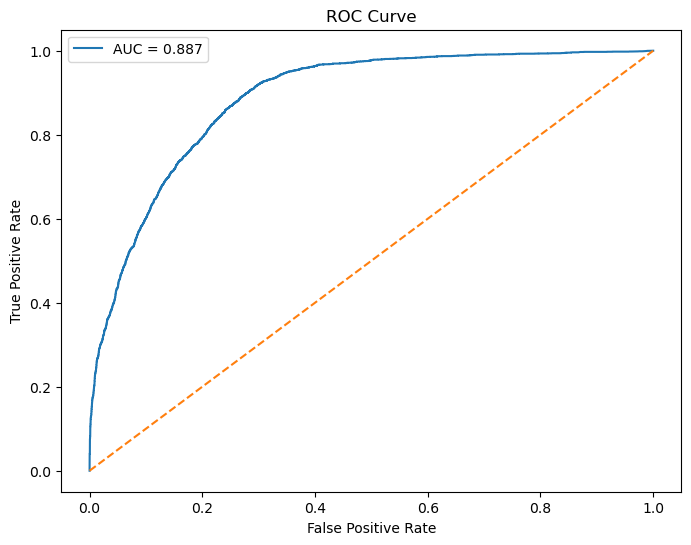

In [11]:
#Graficas
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

9. Importancia de Variables

In [12]:
import pandas as pd

importancias = pd.Series(
    rf_final.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

importancias.head(10)

gender                 0.110382
Gtp                    0.093752
height(cm)             0.084472
triglyceride           0.069380
hemoglobin             0.065891
LDL                    0.049932
Cholesterol            0.048768
ALT                    0.048226
HDL                    0.048192
fasting blood sugar    0.047337
dtype: float64

10. Guardado del Modelo

In [13]:
import joblib

joblib.dump(
    rf_final,
    "../models/random_forest_final.joblib"
)

['../models/random_forest_final.joblib']

In [14]:
#Verificacion

modelo = joblib.load(
    "../models/random_forest_final.joblib"
)

type(modelo)

sklearn.ensemble._forest.RandomForestClassifier

11. Conclusión

El modelo seleccionado fue un Random Forest optimizado mediante GridSearchCV. Sobre el conjunto de prueba obtuvo un F1-score de 0.7356 para la clase positiva. El análisis de la matriz de confusión y la curva ROC muestran una adecuada capacidad de discriminación entre fumadores y no fumadores. 

La matriz de confusión muestra que el modelo identifica correctamente el 75.7% de los fumadores y el 82.5% de los no fumadores. Asimismo, la curva ROC presenta un área bajo la curva (AUC) de 0.887, lo que indica una muy buena capacidad de discriminación entre ambas clases. Estos resultados confirman que el modelo posee un desempeño adecuado para ser utilizado en la etapa de predicción sobre datos no etiquetados.

Las variables más relevantes fueron género, Gtp, altura, triglicéridos y hemoglobina. Finalmente, el modelo fue persistido utilizando joblib para su posterior utilización en la etapa de predicción.